In [1]:
import os
import numpy as np
import torch
import time
import mlflow

from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from sklearn.metrics import f1_score, accuracy_score
from contextlib import contextmanager

from src.resnet import ResNet18
from src.pca import PCATransformer
from src.draw_figures import *
from src.dataloader import CIFARCustom
# from src.umap import UMAPTransformer




device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlflow.set_experiment("Separability_methods")

seed = 42
target = 1
epoch = 15

%matplotlib inline

%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
timings = {}

@contextmanager
def timer(name: str):
    start = time.perf_counter()
    elapsed = time.perf_counter() - start
    timings[name] = elapsed
    print(f"[TIMER] {name}: {elapsed:.4f} s")


In [3]:
# filename = "./metrics_new_pipeline.csv"
# with open(filename, mode='a', newline='') as file:
#     writer = csv.writer(file)
    
    # writer.writerow([
    #     'target', 
    #     'lda_f1_score',
    #     'linearSVC_f1_score',
    #     'logistic_regression_f1_score', 
    #     'random_forest_f1_score',
    #     'xgboost_f1_score',
    #     'knn_f1_score',
    # ])

### 1. Подготовка данных:

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


generator = torch.Generator().manual_seed(seed)
os.makedirs(f"./output/{target}", exist_ok=True) 


### То, на чем обучаем resnet, строим pca
train_dataset = CIFARCustom(
    root="./data",
    exclude_class=[target],
    train=True, 
    transform=transform
)

train_size = int(0.8 * len(train_dataset))
val_size = int(0.15 * len(train_dataset))

# выборка для построение PCA пространства, для тренеровки модели разделения
test_size = (len(train_dataset) - train_size - val_size) // 2 
# выбока, которая отрпаится в финальный тест нового пайплайна
new_pipeline_test_size = len(train_dataset) - train_size - val_size - test_size


train, val, test, new_pipeline_test = random_split(
    train_dataset, 
    [train_size, val_size, test_size, new_pipeline_test_size], 
    generator=generator
)

train_loader = DataLoader(train, batch_size=64, shuffle=True, num_workers=2, generator=generator)
val_loader   = DataLoader(val, batch_size=64, shuffle=False, num_workers=2, generator=generator)
test_loader = DataLoader(test, batch_size=64, shuffle=False, num_workers=2, generator=generator)

### То, на чем делаем холостой (все классы будует неверные) предикт ради feature layer, на чем обучаем и проводим тесты lda
target_dataset = CIFARCustom(
    root="./data",
    exclude_class=[i for i in range(10) if i != target],
    train=True, 
    transform=transform
)

target_train_size = int(0.85 * len(target_dataset))
target_test_size = (len(target_dataset) - target_train_size)
other = len(target_dataset) - target_train_size - target_test_size

train_target, test_target, other = random_split(
    target_dataset, 
    [target_train_size, target_test_size, other]
)

train_target_loader = DataLoader(train_target, batch_size=64, shuffle=True, num_workers=2, generator=generator)
test_target_loader = DataLoader(test_target, batch_size=64, shuffle=True, num_workers=2, generator=generator)

### То, на чем пробуем новый пайплайн
new_pipeline_loader = DataLoader(new_pipeline_test+test_target, batch_size=64, shuffle=True, num_workers=2, generator=generator)


In [5]:
mlflow.start_run(run_name=f"exclude_class_{target}_epoch{epoch}")

mlflow.log_params({
    "target": target,
    "seed": seed,
})

In [6]:
len(train_dataset), len(target_dataset), len(train), len(val), len(test), len(new_pipeline_test)

(45000, 5000, 36000, 6750, 1125, 1125)

In [7]:
len(train_target), len(test_target), len(new_pipeline_loader)

(4250, 750, 30)

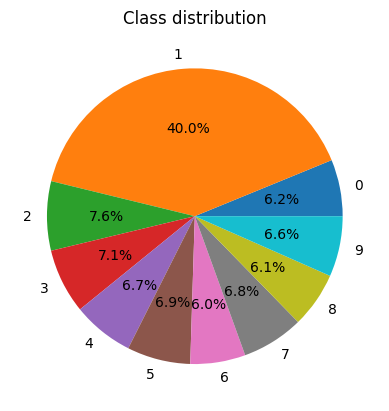

In [8]:
class_distr_path = class_distribution(
    new_pipeline_loader,
    f"output/{target}/new_pipeline_class_distribution.png"
)


mlflow.log_artifact(class_distr_path)

### 2. Подгружаем модель:

In [9]:
resnet = ResNet18(
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        device=device,
        learning_rate=0.001,
        # num_epochs=8,
        weights=f"./models/resnet18_cifar10_without{target}_epoch_{epoch}.pth"
    )

# history = resnet.train()

Loaded weights from ./models/resnet18_cifar10_without1_epoch_15.pth


### 3. Извлекаем признаки и строим пространство:

f1-мера (глобальные TP и FP): 0.7193195368846633, 
По каждому классу: [0.77777778 0.54028436 0.52713178 0.66945607 0.63082437 0.78676471
 0.80851064 0.86554622 0.86757991]


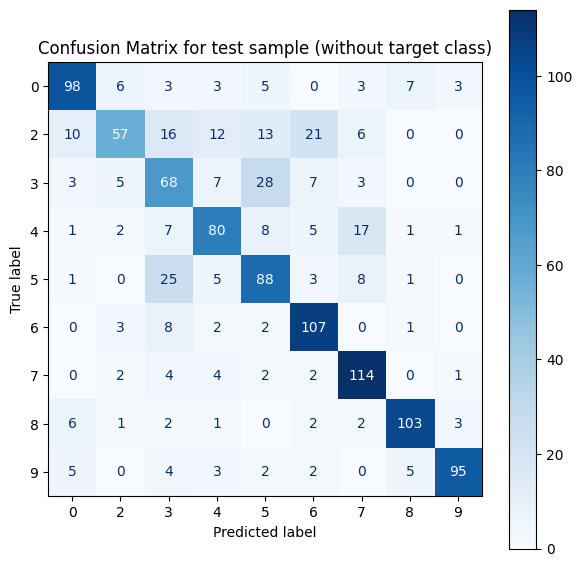

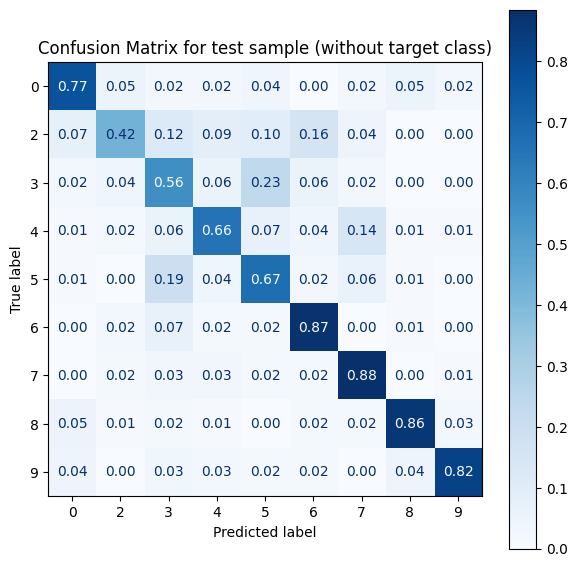

In [10]:
test_cifar9_features, test_cifar9_preds, test_cifar9_gt_preds = resnet.extract_features(test_loader)
test_cifar9_iscorrect = test_cifar9_gt_preds == test_cifar9_preds

mask = test_cifar9_gt_preds == test_cifar9_preds
test_cifar9_CR = test_cifar9_features[mask == True]
test_cifar9_WR = test_cifar9_features[mask == False]

test_cifar9_f1_score =  f1_score(test_cifar9_gt_preds, test_cifar9_preds, average="macro")
test_cifar9_f1_score_list = f1_score(test_cifar9_gt_preds, test_cifar9_preds, average=None)

print("f1-мера (глобальные TP и FP): {}, \nПо каждому классу: {}".format(
        test_cifar9_f1_score,
        test_cifar9_f1_score_list
    )
)
class_names = [str(i) for i in range(10) if i != target]


conf_martix_path = plot_confusion_matrix(
    test_cifar9_preds, 
    test_cifar9_gt_preds, 
    class_names=class_names,
    title="Confusion Matrix for test sample (without target class)",
    path=f"output/{target}/train/confusion_matrix.png"
)

# print(conf_martix_path)

conf_norm_martix_path = plot_confusion_matrix(
    test_cifar9_preds, 
    test_cifar9_gt_preds, 
    class_names=class_names,
    title="Confusion Matrix for test sample (without target class)",
    path=f"output/{target}/train/confusion_norm_matrix.png",
    normalize="true"
)


In [11]:
mlflow.log_artifact(conf_martix_path, artifact_path="Test_loader") 
mlflow.log_artifact(conf_norm_martix_path, artifact_path="Test_loader") 

mlflow.log_metric("test_f1_macro", test_cifar9_f1_score)

for cls, f1 in zip(class_names, test_cifar9_f1_score_list):
        mlflow.log_metric(f"test_f1_class_{cls}", f1)

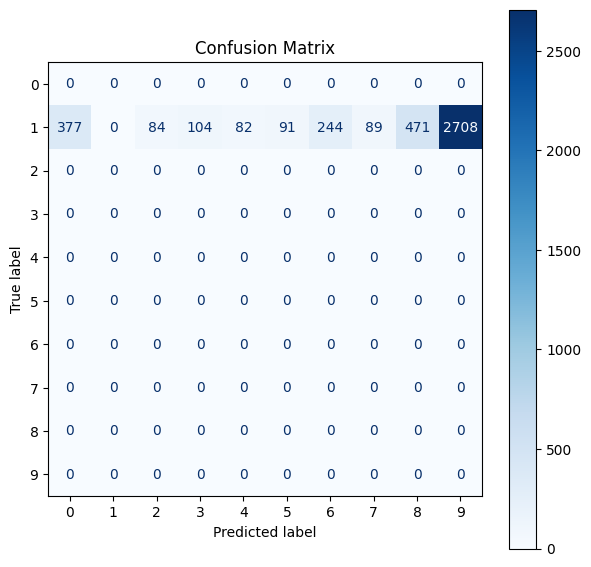

In [12]:
train_target_features, train_target_preds, train_target_gt_preds = resnet.extract_features(train_target_loader)

mask = train_target_gt_preds == train_target_preds
train_target_CR = train_target_features[mask == True]  
train_target_WR = train_target_features[mask == False] 

len(train_target_CR), len(train_target_WR)

plot_confusion_matrix(train_target_preds, train_target_gt_preds)

#### 3.1 Строим PCA пространство:

Финальное количество главных компонент: 24
Объяснённая дисперсия: 0.949


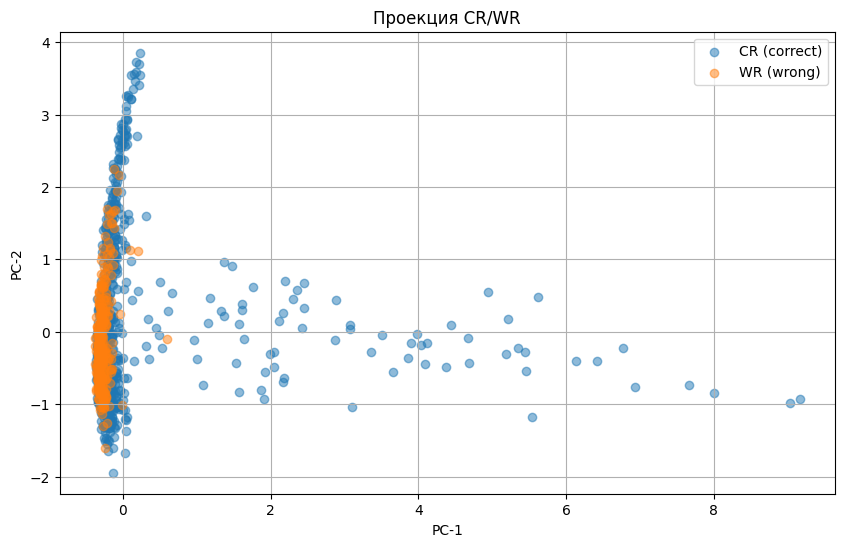

np.int64(24)

In [13]:
pca = PCATransformer(whiten=True) 
pca.fit(test_cifar9_features)


test_cifar9_CR_p = pca.transform(test_cifar9_CR)
test_cifar9_WR_p = pca.transform(test_cifar9_WR)

                            
pca_path = plot_projection(test_cifar9_CR_p, test_cifar9_WR_p, path=f"output/{target}/pca/proj.png")
# plot_projection(test_cifar9_CR_p, test_cifar9_WR_p)

mlflow.log_artifact(pca_path, "PCA")

mlflow.log_param("pca_components", pca.n_components)

In [14]:
test_cifar9_features_p = pca.transform(test_cifar9_features)

print("Проецирование всех test данных:")
plot_embedding_3d(test_cifar9_features_p, test_cifar9_gt_preds.astype(str))

Проецирование всех test данных:


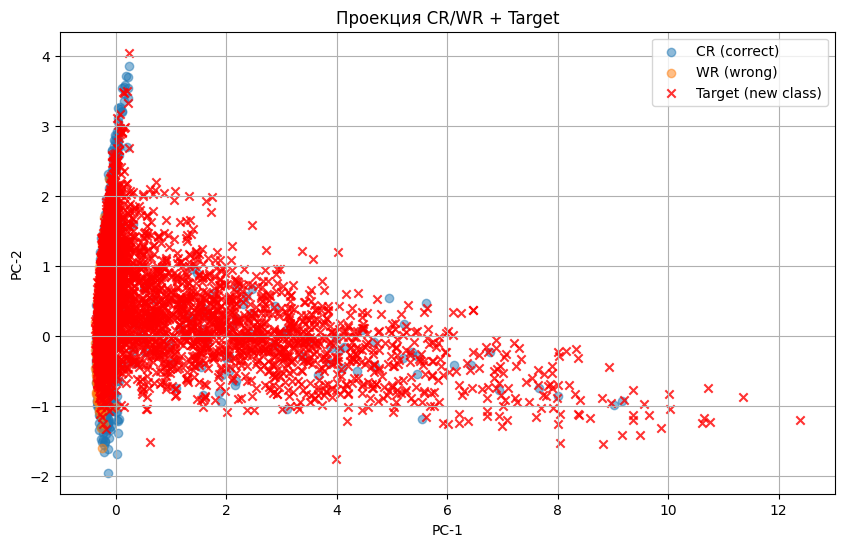

In [15]:
train_target_p = pca.transform(train_target_features)
target_pca_path = plot_projection(test_cifar9_CR_p, test_cifar9_WR_p, target_data=train_target_p, path=f"output/{target}/pca/proj_with_target.png")
# plot_projection(test_cifar9_CR_p, test_cifar9_WR_p, target_data=train_target_p)

mlflow.log_artifact(target_pca_path, "PCA")

In [16]:
test_cifar9_features_p_with_target_p = np.vstack((test_cifar9_features_p, train_target_p))
test_cifar9_gt_preds_with_target = np.concatenate((test_cifar9_gt_preds, train_target_gt_preds))

print(f"Проецирование всех test данных c target классом ({target}):")
plot_embedding_3d(test_cifar9_features_p_with_target_p, test_cifar9_gt_preds_with_target.astype(str))

Проецирование всех test данных c target классом (1):


### 4. Разделяем пространство:

In [17]:
X_pca = np.vstack((test_cifar9_CR_p, test_cifar9_WR_p, train_target_p))

print(len(test_cifar9_CR_p)+len(test_cifar9_WR_p), len(train_target_p))
# 0 = старые классы (CR+WR), 1 = новый unseen класс
y_pca = np.hstack((
    np.zeros(len(test_cifar9_CR_p) + len(test_cifar9_WR_p)),
    np.ones(len(train_target_p))
))

1125 4250


#### 4.1 LDA:

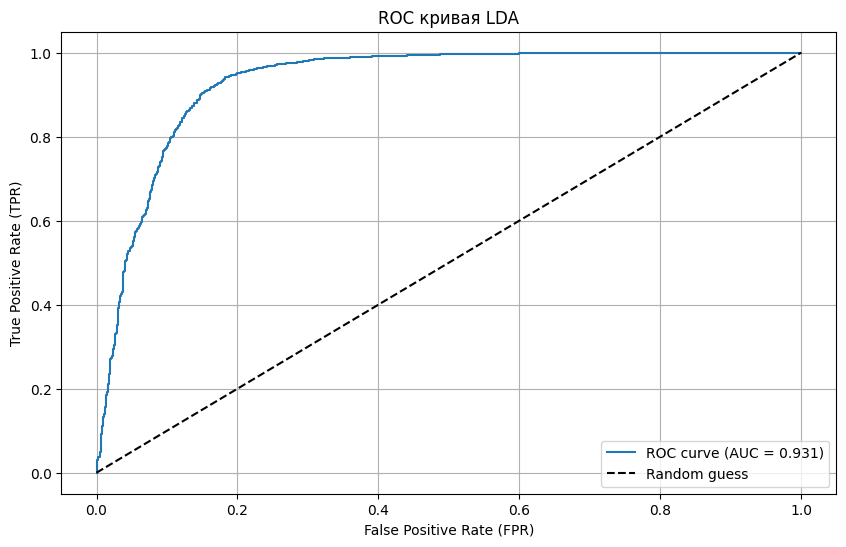

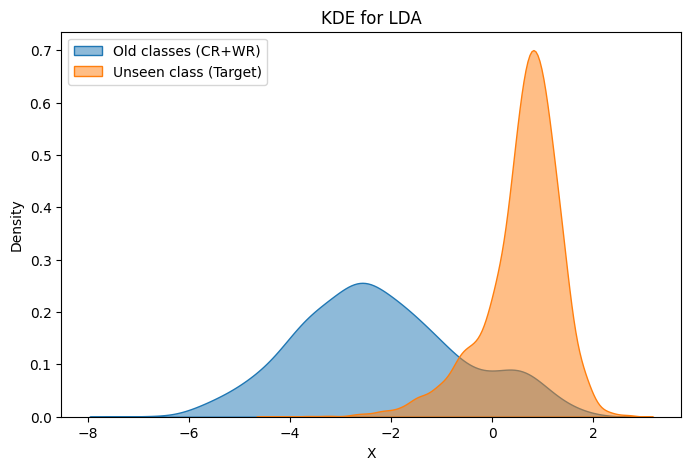

1

In [18]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# with timer("ROC/AUC for lda"):
lda_on_pca = LinearDiscriminantAnalysis(n_components=1)
X_pca_lda = lda_on_pca.fit_transform(X_pca, y_pca)


scores = X_pca_lda.ravel()  

# lda_pca_auc = plot_roc_auc(scores, y_pca, path=f"output/{target}/pca_roc_auc_for_lda.png")
lda_pca_auc, roc_auc_path = plot_roc_auc(
    scores, 
    y_pca,
    path=f"output/{target}/lda/ROC_AUC.png"
)

kde_path = plot_kde(
    X_pca_lda, 
    y_pca, 
    path=f"output/{target}/lda/kde.png"
)


mlflow.log_artifact(roc_auc_path, "lda")
mlflow.log_artifact(kde_path, "lda")
mlflow.log_metric("lda_auc_score", lda_pca_auc)
mlflow.log_param("lda_components", lda_on_pca.n_components)


#### 4.2 Lineral SVM:

https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html

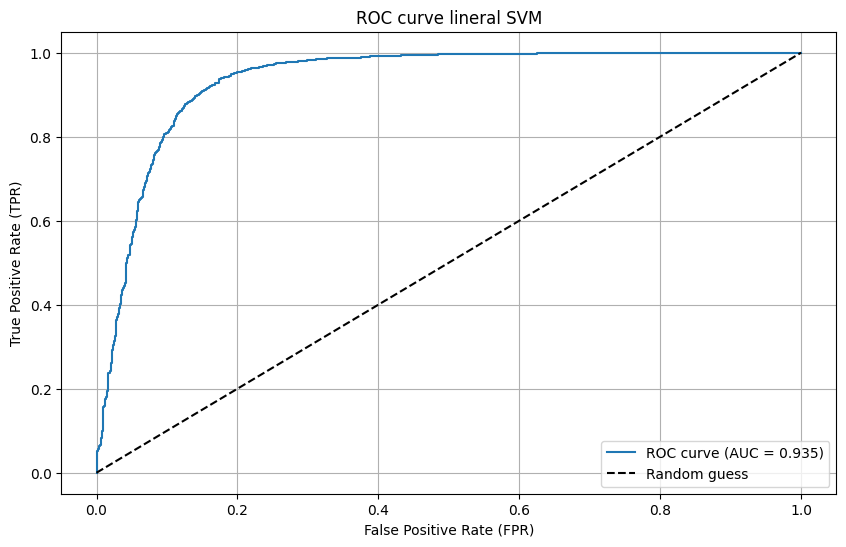

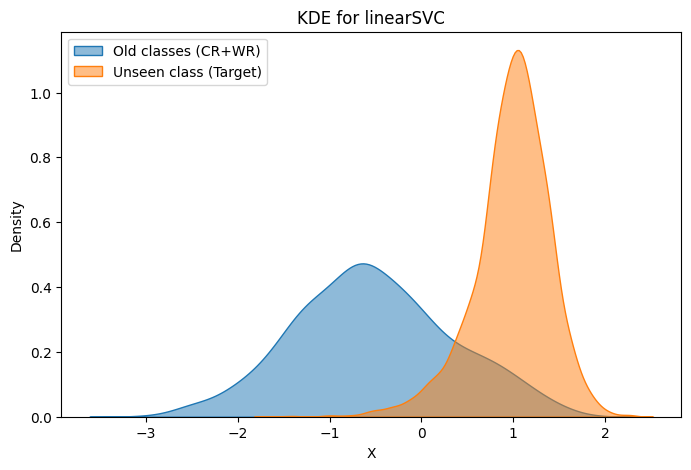

In [19]:
from sklearn.svm import LinearSVC

# with timer("ROC/AUC for LSVC"):
lsvc_on_pca = LinearSVC(dual=False)  
lsvc_on_pca.fit(X_pca, y_pca)

scores = lsvc_on_pca.decision_function(X_pca).ravel()

lsvc_pca_auc, roc_curve_path = plot_roc_auc(
    scores, 
    y_pca, 
    title="ROC curve lineral SVM",
    path=f"output/{target}/linearSVC/ROC_AUC.png"
)

X_pca_svm = lsvc_on_pca.decision_function(X_pca).reshape(-1, 1)
kde_path = plot_kde(
    X_pca_svm, 
    y_pca,
    title="KDE for linearSVC",
    path=f"output/{target}/linearSVC/kde.png"
)

mlflow.log_artifact(roc_auc_path, "linearSVC")
mlflow.log_artifact(kde_path, "linearSVC")
mlflow.log_metric("linearSVC_auc_score", lsvc_pca_auc)

#### 4.3 Логистическая регрсессия

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

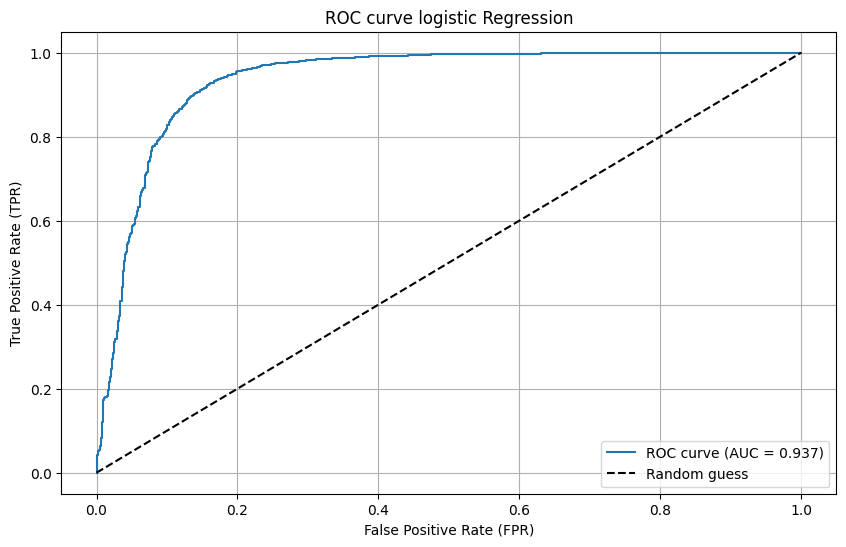

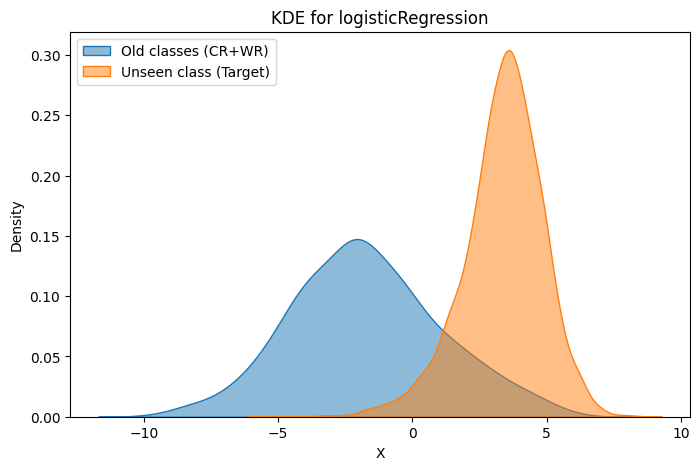

'liblinear'

In [20]:
from sklearn.linear_model import LogisticRegression

# LogisticRegression is supervised - uses labels like LDA and LinearSVC
# with timer("ROC/AUC for LR"):
lr_on_pca = LogisticRegression(solver='liblinear')
lr_on_pca.fit(X_pca, y_pca)

scores = lr_on_pca.decision_function(X_pca).ravel()

lr_pca_auc, roc_auc_path = plot_roc_auc(
    scores, 
    y_pca, 
    title="ROC curve logistic Regression",
    path=f"output/{target}/logisticRegression/ROC_AUC.png"

)

X_pca_lr = lr_on_pca.decision_function(X_pca).reshape(-1, 1)
kde_path = plot_kde(
    X_pca_lr, 
    y_pca,
    title="KDE for logisticRegression",
    path=f"output/{target}/logisticRegression/kde.png"
)

mlflow.log_artifact(roc_auc_path, "logisticRegression")
mlflow.log_artifact(kde_path, "logisticRegression")
mlflow.log_metric("logisticRegression_auc_score", lr_pca_auc)
mlflow.log_param("logisticRegression_solver", lr_on_pca.solver)

#### 4.4 RandomForest

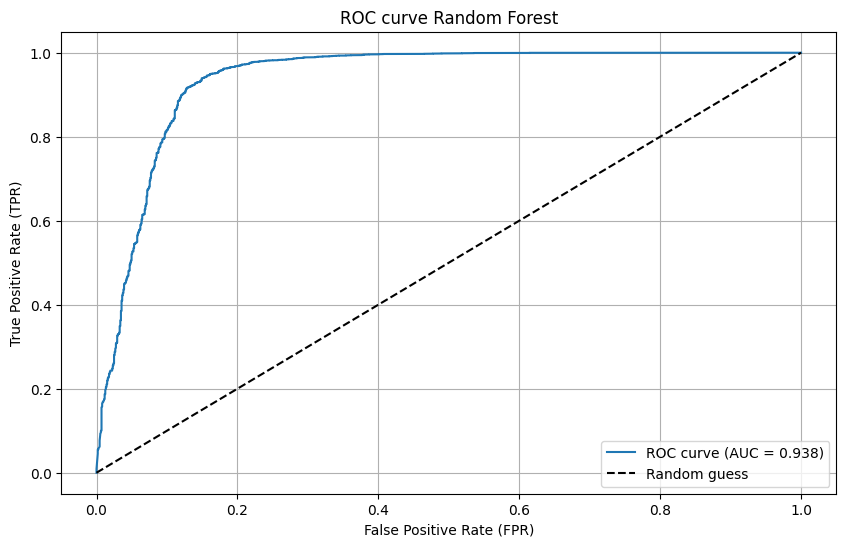

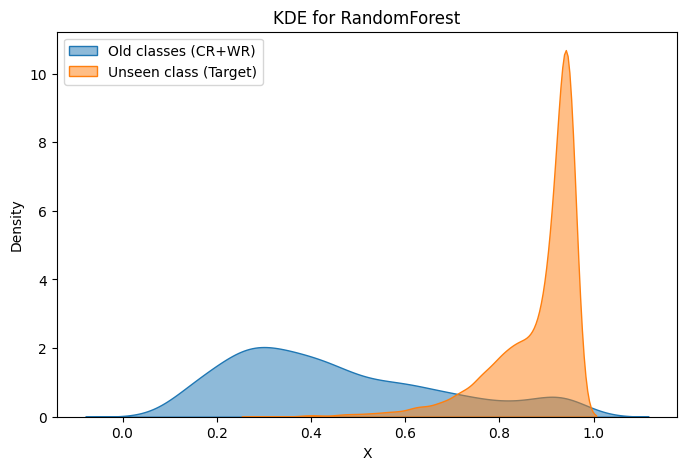

In [27]:
from sklearn.ensemble import RandomForestClassifier

# with timer("ROC/AUC for rf"):
rf_on_pca = RandomForestClassifier(
    n_estimators=50,                   
    max_depth=5,             
    # min_samples_split=10,     
    # min_samples_leaf=5,       
    # max_features='sqrt',       
    random_state=seed,           
    n_jobs=-1                 
)
rf_on_pca.fit(X_pca, y_pca)


scores = rf_on_pca.predict_proba(X_pca)[:, 1].ravel()

rf_pca_auc, roc_auc_path = plot_roc_auc(
    scores, 
    y_pca, 
    title="ROC curve Random Forest",
    path=f"output/{target}/randomForestClassifier/ROC_AUC.png"
)

X_pca_rf = rf_on_pca.predict_proba(X_pca)[:, 1].reshape(-1, 1)
kde_path = plot_kde(
    X_pca_rf, 
    y_pca,
    title="KDE for RandomForest",
    path=f"output/{target}/randomForestClassifier/kde.png"
)


mlflow.log_artifact(roc_auc_path, "randomForestClassifier")
mlflow.log_artifact(kde_path, "randomForestClassifier")
mlflow.log_metric("randomForestClassifier", rf_pca_auc)
mlflow.log_params({
    "randomForestClassifier": rf_on_pca.n_estimators,
    "randomForestClassifier": rf_on_pca.max_depth,
})


#### 4.5 XGBoost:

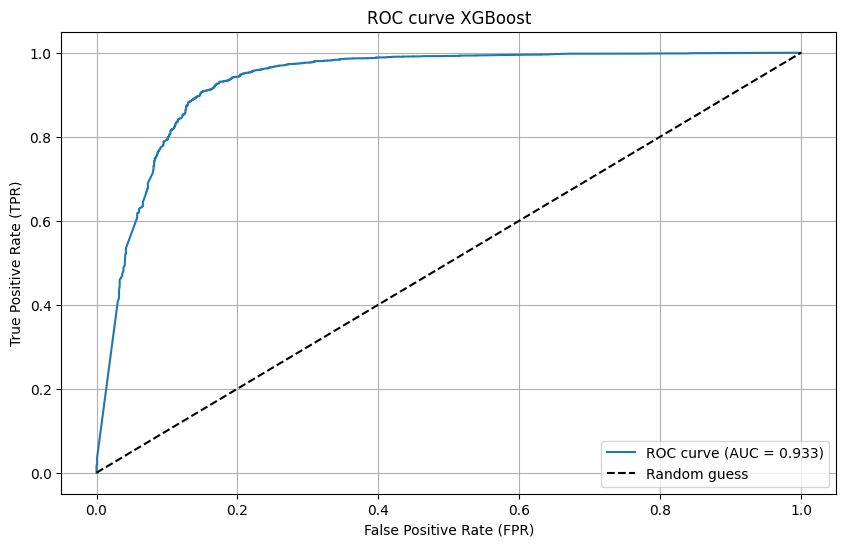

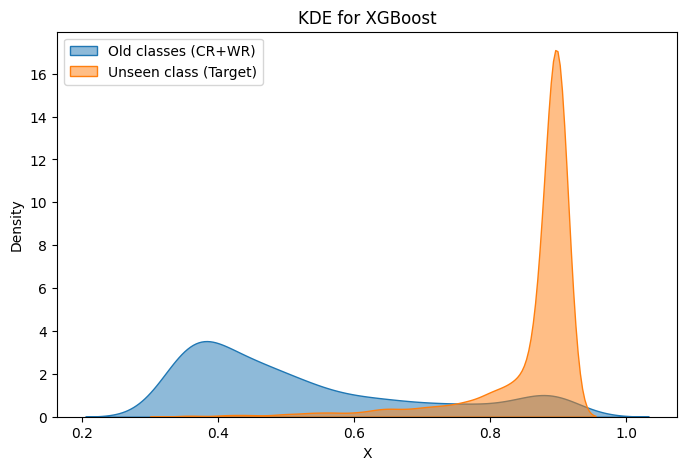

In [39]:
from xgboost import XGBClassifier

# with timer("ROC\AUC for xgb"):
xgb_on_pca = XGBClassifier(
    n_estimators=20,          # More trees to compensate for lower learning_rate
    max_depth=4,               # Reduced from 6 - shallower trees prevent overfitting
    learning_rate=0.05,        
    # subsample=0.7,            
    # colsample_bytree=0.7,     
    # min_child_weight=5,        
    # gamma=0.1,                
    # reg_alpha=0.5,           
    # reg_lambda=2.0,           
    random_state=seed,         
    n_jobs=-1,                
    # eval_metric='logloss'      
)
xgb_on_pca.fit(X_pca, y_pca)


scores = xgb_on_pca.predict_proba(X_pca)[:, 1].ravel()

xgb_pca_auc, roc_auc_path = plot_roc_auc(
    scores, 
    y_pca, 
    title="ROC curve XGBoost",
    path=f"output/{target}/xgbClassifier/ROC_AUC.png"
)

X_pca_xgb = xgb_on_pca.predict_proba(X_pca)[:, 1].reshape(-1, 1)
kde_path = plot_kde(
    X_pca_xgb, 
    y_pca,
    title="KDE for XGBoost",
    path=f"output/{target}/xgbClassifier/kde.png"
)

# mlflow.log_artifact(roc_auc_path, "xgbClassifier")
# mlflow.log_artifact(kde_path, "xgbClassifier")
# mlflow.log_metric("xgbClassifier_auc_score", xgb_pca_auc)
# mlflow.log_params({
#     "xgbClassifier_n": xgb_on_pca.n_estimators,
#     "xgbClassifier_max_depth": xgb_on_pca.max_depth,
#     "xgbClassifier_lr": xgb_on_pca.learning_rate,
#     "xgbClassifier_eval_metric": xgb_on_pca.eval_metric,
# })

#### 4.6 KNN (k-Nearest Neighbors)

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html


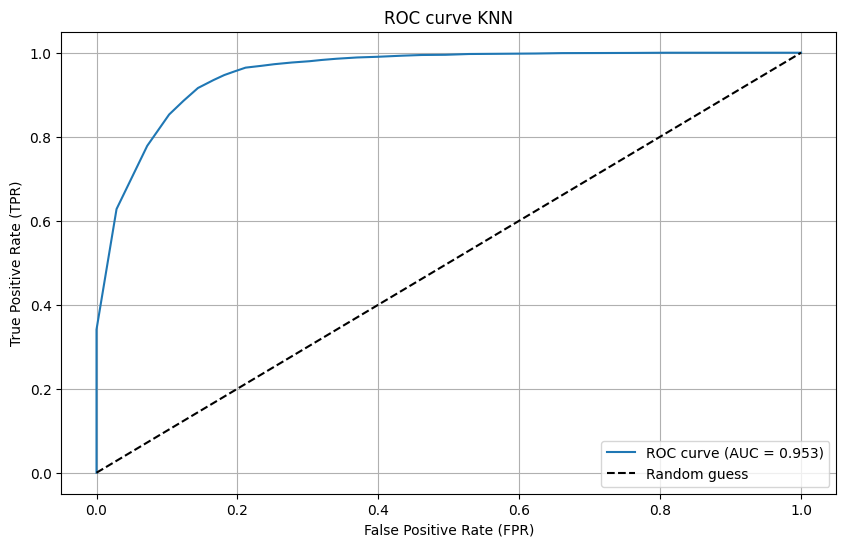

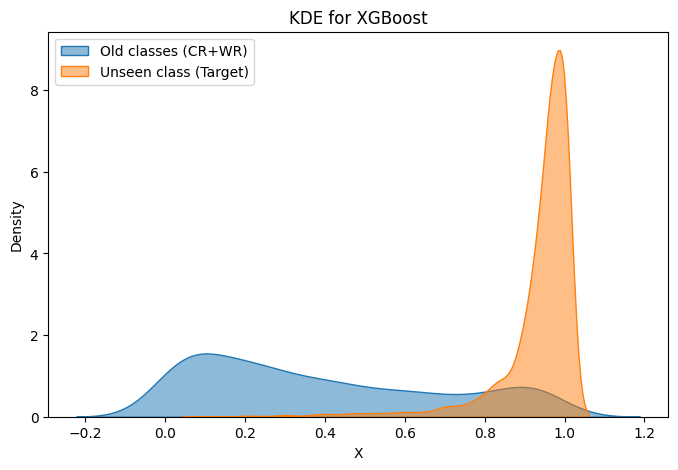

MlflowException: Changing param values is not allowed. Param with key='knn_n' was already logged with value='5' for run ID='9a7ba4722b344d80a3dc9129db6037e1'. Attempted logging new value '30'.

The cause of this error is typically due to repeated calls
to an individual run_id event logging.

Incorrect Example:
---------------------------------------
with mlflow.start_run():
    mlflow.log_param("depth", 3)
    mlflow.log_param("depth", 5)
---------------------------------------

Which will throw an MlflowException for overwriting a
logged parameter.

Correct Example:
---------------------------------------
with mlflow.start_run():
    with mlflow.start_run(nested=True):
        mlflow.log_param("depth", 3)
    with mlflow.start_run(nested=True):
        mlflow.log_param("depth", 5)
---------------------------------------

Which will create a new nested run for each individual
model and prevent parameter key collisions within the
tracking store.

In [44]:
from sklearn.neighbors import KNeighborsClassifier


# with timer("ROC\AUC for knn"):
knn_on_pca = KNeighborsClassifier(
    n_neighbors=30,                      
    n_jobs=-1
)
knn_on_pca.fit(X_pca, y_pca)

# Probability of class 1 (unseen class)
scores = knn_on_pca.predict_proba(X_pca)[:, 1].ravel()

knn_pca_auc, roc_auc_path = plot_roc_auc(
    scores, 
    y_pca, 
    title="ROC curve KNN",
    path=f"output/{target}/knn/ROC_AUC.png"
)

X_pca_knn = knn_on_pca.predict_proba(X_pca)[:, 1].reshape(-1, 1)
kde_path = plot_kde(
    X_pca_knn, 
    y_pca,
    title="KDE for XGBoost",
    path=f"output/{target}/knn/kde.png"
)

mlflow.log_artifact(roc_auc_path, "knn")
mlflow.log_artifact(kde_path, "knn")
mlflow.log_metric("knn_auc_score", knn_pca_auc)
mlflow.log_param("knn_n", knn_on_pca.n_neighbors)


### 5. Новый пайплайн:

In [45]:
all_classes = [i for i in range(10)]
features, preds, gt_preds = resnet.extract_features(new_pipeline_loader)

def new_pipeline(features: np.array, preds: np.array, sep_model, proj):
    features_p = proj.transform(features)


    # se_predict =  np.where(lda.predict_proba(features_p)[:, 1] > thresh, 1, 0)
    sep_predict = sep_model.predict(features_p)

    predict = []
    for i in range(sep_predict.shape[0]):
        if sep_predict[i]:
            predict.append(target)
        else:
            predict.append(preds[i])

    return np.array(predict)

def print_metric(preds, gt_preds):
    # https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html
    new_pipeline_loader_f1_score_macro = f1_score(preds, gt_preds, average="macro")
    new_pipeline_loader_f1_score_micro = f1_score(preds, gt_preds, average="micro")
    new_pipeline_loader_f1_score_list = f1_score(preds, gt_preds, average=None)
    new_pipeline_loader_acc = accuracy_score(preds, gt_preds)

    print("f1-мера (глобальные TP и FP): {} \nf1-score (усреднее): {}" \
    "\nf1-score (по каждому классу): {} \nacc: {}".format(
        new_pipeline_loader_f1_score_macro,
        new_pipeline_loader_f1_score_micro,
        new_pipeline_loader_f1_score_list,
        new_pipeline_loader_acc
        )
    )

    return new_pipeline_loader_f1_score_macro, new_pipeline_loader_f1_score_list


In [46]:
len(features)

1875

f1-мера (глобальные TP и FP): 0.6066940028623157 
f1-score (усреднее): 0.7141333333333333
f1-score (по каждому классу): [0.68341709 0.82459109 0.63203463 0.51428571 0.69803922 0.64963504
 0.75229358 0.71264368 0.6        0.        ] 
acc: 0.7141333333333333


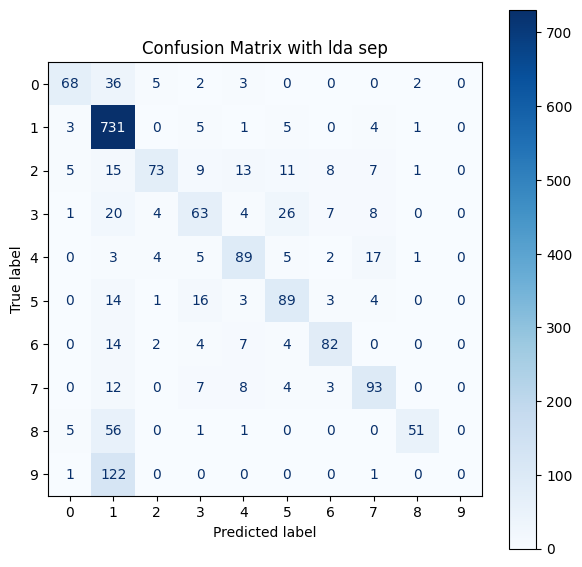

In [47]:
preds_pca = new_pipeline(features, preds, lda_on_pca, pca)
new_pileine_f1_macro, new_pipeline_f1_list = print_metric(preds_pca, gt_preds)

new_pipeline_conf_m = plot_confusion_matrix(
    preds_pca, 
    gt_preds, 
    title="Confusion Matrix with lda sep",
    path=f"output/{target}/lda/new_pipeline_confusion_matrix.png"
)

mlflow.log_artifact(new_pipeline_conf_m, "lda")
mlflow.log_metric("new_pipeline_lda_f1_macro", new_pileine_f1_macro)
for cls, f1 in zip(all_classes, new_pipeline_f1_list):
        mlflow.log_metric(f"new_pipeline_lda_f1_class_{cls}", f1)


f1-мера (глобальные TP и FP): 0.6135160388048425 
f1-score (усреднее): 0.7184
f1-score (по каждому классу): [0.6969697  0.82665161 0.62608696 0.51851852 0.7007874  0.64492754
 0.75       0.73076923 0.64044944 0.        ] 
acc: 0.7184


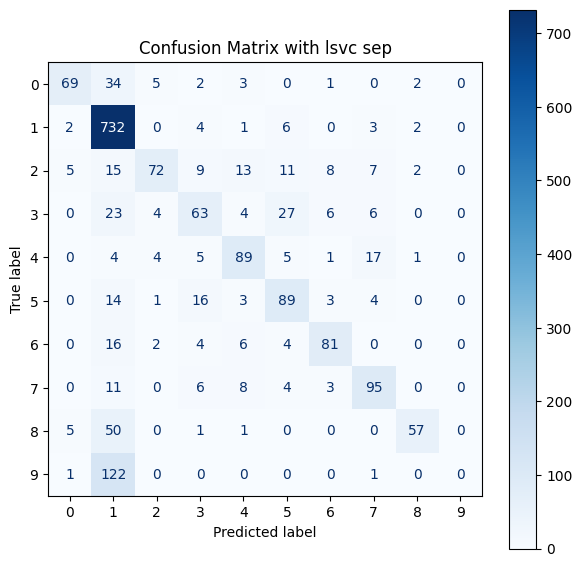

In [48]:
preds_pca = new_pipeline(features, preds, lsvc_on_pca, pca)
new_pileine_f1_macro, new_pipeline_f1_list = print_metric(preds_pca, gt_preds)

new_pipeline_conf_m = plot_confusion_matrix(
    preds_pca, 
    gt_preds, 
    title="Confusion Matrix with lsvc sep",
    path=f"output/{target}/linearSVC/new_pipeline_confusion_matrix.png"
)

mlflow.log_artifact(new_pipeline_conf_m, "linearSVC")
mlflow.log_metric("new_pipeline_linearSVC_f1_macro", new_pileine_f1_macro)
for cls, f1 in zip(all_classes, new_pipeline_f1_list):
        mlflow.log_metric(f"new_pipeline_linearSVC_f1_class_{cls}", f1)

f1-мера (глобальные TP и FP): 0.614923268401324 
f1-score (усреднее): 0.7184
f1-score (по каждому классу): [0.69346734 0.8261851  0.62280702 0.51639344 0.7007874  0.64492754
 0.74418605 0.73643411 0.64804469 0.016     ] 
acc: 0.7184


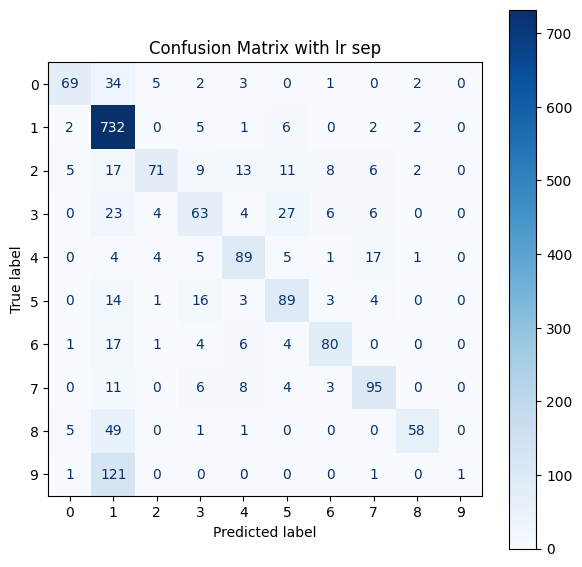

In [49]:
preds_pca = new_pipeline(features, preds, lr_on_pca, pca)
new_pileine_f1_macro, new_pipeline_f1_list = print_metric(preds_pca, gt_preds)

new_pipeline_conf_m = plot_confusion_matrix(
    preds_pca, 
    gt_preds, 
    title="Confusion Matrix with lr sep",
    path=f"output/{target}/logisticRegression/new_pipeline_confusion_matrix.png"
)

mlflow.log_artifact(new_pipeline_conf_m, "logisticRegression")
mlflow.log_metric("new_pipeline_logisticRegression_f1_macro", new_pileine_f1_macro)
for cls, f1 in zip(all_classes, new_pipeline_f1_list):
        mlflow.log_metric(f"new_pipeline_logisticRegression_f1_class_{cls}", f1)

f1-мера (глобальные TP и FP): 0.5486945255752833 
f1-score (усреднее): 0.664
f1-score (по каждому классу): [0.60335196 0.76038994 0.53588517 0.47488584 0.6779661  0.64393939
 0.65957447 0.71428571 0.41666667 0.        ] 
acc: 0.664


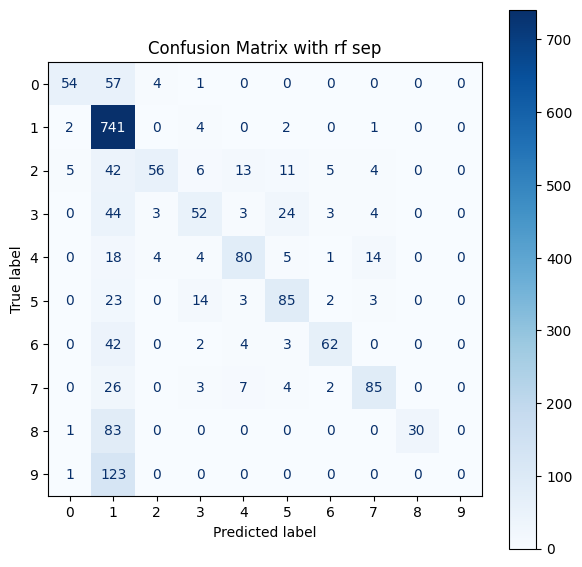

In [50]:
preds_pca = new_pipeline(features, preds, rf_on_pca, pca)
new_pileine_f1_macro, new_pipeline_f1_list = print_metric(preds_pca, gt_preds)

new_pipeline_conf_m = plot_confusion_matrix(
    preds_pca, 
    gt_preds, 
    title="Confusion Matrix with rf sep",
    path=f"output/{target}/randomForestClassifier/new_pipeline_confusion_matrix.png"
)

mlflow.log_artifact(new_pipeline_conf_m, "randomForestClassifier")
mlflow.log_metric("new_pipeline_randomForestClassifier_f1_macro", new_pileine_f1_macro)
for cls, f1 in zip(all_classes, new_pipeline_f1_list):
        mlflow.log_metric(f"new_pipeline_randomForestClassifier_f1_class_{cls}", f1)

f1-мера (глобальные TP и FP): 0.5400777698373915 
f1-score (усреднее): 0.6512
f1-score (по каждому классу): [0.6        0.74159558 0.54807692 0.42424242 0.675      0.63900415
 0.7254902  0.6        0.44736842 0.        ] 
acc: 0.6512


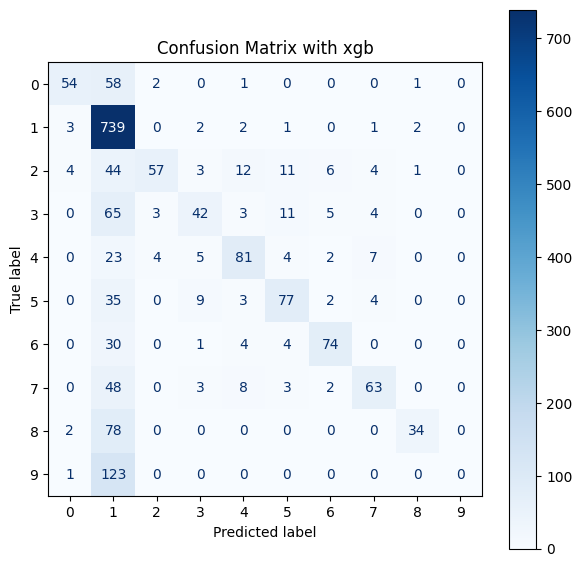

f1-мера (глобальные TP и FP): 0.5400777698373915 
f1-score (усреднее): 0.6512
f1-score (по каждому классу): [0.6        0.74159558 0.54807692 0.42424242 0.675      0.63900415
 0.7254902  0.6        0.44736842 0.        ] 
acc: 0.6512


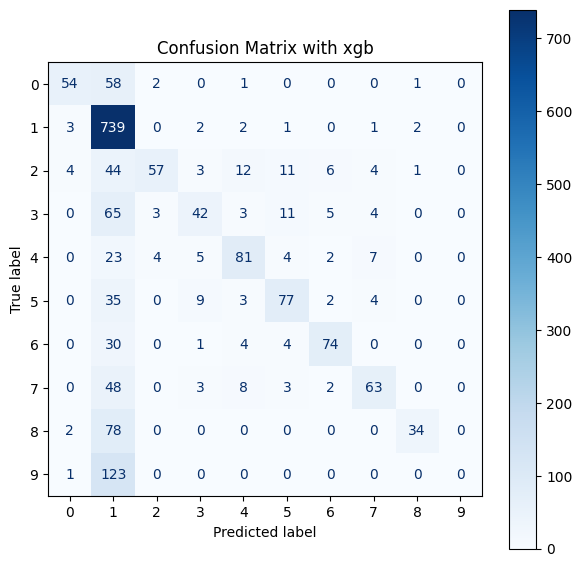

In [52]:
preds_pca = new_pipeline(features, preds, xgb_on_pca, pca)
print_metric(preds_pca, gt_preds)

plot_confusion_matrix(preds_pca, gt_preds, title="Confusion Matrix with xgb")


preds_pca = new_pipeline(features, preds, xgb_on_pca, pca)
new_pileine_f1_macro, new_pipeline_f1_list = print_metric(preds_pca, gt_preds)

new_pipeline_conf_m = plot_confusion_matrix(
    preds_pca, 
    gt_preds, 
    title="Confusion Matrix with xgb",
    path=f"output/{target}/xgbClassifier/new_pipeline_confusion_matrix.png"
)

mlflow.log_artifact(new_pipeline_conf_m, "xgbClassifier")
mlflow.log_metric("new_pipeline_xgbClassifierr_f1_macro", new_pileine_f1_macro)
for cls, f1 in zip(all_classes, new_pipeline_f1_list):
        mlflow.log_metric(f"new_pipeline_xgbClassifier_f1_class_{cls}", f1)

f1-мера (глобальные TP и FP): 0.5831486555089883 
f1-score (усреднее): 0.6912
f1-score (по каждому классу): [0.63736264 0.79332616 0.58333333 0.5021645  0.68016194 0.67158672
 0.71153846 0.67213115 0.57988166 0.        ] 
acc: 0.6912


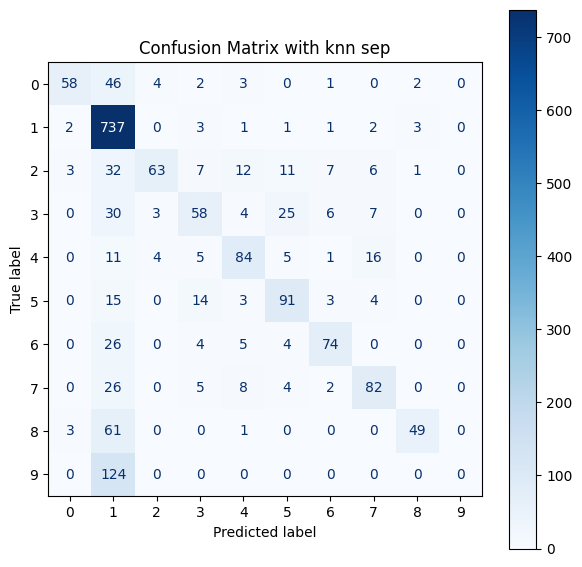

In [53]:
preds_pca = new_pipeline(features, preds, knn_on_pca, pca)
new_pileine_f1_macro, new_pipeline_f1_list = print_metric(preds_pca, gt_preds)

new_pipeline_conf_m = plot_confusion_matrix(
    preds_pca, 
    gt_preds, 
    title="Confusion Matrix with knn sep",
    path=f"output/{target}/knn/new_pipeline_confusion_matrix.png"
)

mlflow.log_artifact(new_pipeline_conf_m, "knn")
mlflow.log_metric("new_pipeline_knn_f1_macro", new_pileine_f1_macro)
for cls, f1 in zip(all_classes, new_pipeline_f1_list):
        mlflow.log_metric(f"new_pipeline_knn_f1_class_{cls}", f1)

In [54]:
mlflow.end_run()